# Importing and Querying Data with PostgreSQL (Northwind Database)

Describtion of the Northwind Database: https://en.wikiversity.org/wiki/Database_Examples/Northwind 

Example SQL-Queries based on the Northwind Database: https://www.w3schools.com/sql/default.asp

SQL Tutorials: https://www.youtube.com/watch?v=zpnHsWOy0RY&list=PLP9IO4UYNF0UQkBXlTMSw0CYsxv-GDkkI

## Frequently used SQL clauses (for in-depth learning)

<div>
  <style>
    .sql-keyword {
      color: white;
    }
  </style>
  <span class="sql-keyword">SELECT</span><br>
  <span class="sql-keyword">SELECT DISTINCT</span><br>
  <span class="sql-keyword">FROM</span><br>
  <span class="sql-keyword">WHERE</span><br>
  <span class="sql-keyword">AND</span><br>
  <span class="sql-keyword">LIKE</span><br>
  <span class="sql-keyword">GROUP BY</span><br>
  <span class="sql-keyword">HAVING</span><br>
  <span class="sql-keyword">ORDER BY</span><br>
  <span class="sql-keyword">FULL JOIN</span><br>
  <span class="sql-keyword">INNER JOIN</span><br>
  <span class="sql-keyword">LEFT JOIN</span><br>
  <span class="sql-keyword">RIGHT JOIN</span><br>
  <span class="sql-keyword">ON</span><br>
  <span class="sql-keyword">LIMIT</span><br>
  <span class="sql-keyword">AS</span><br>
  <span class="sql-keyword">AVG</span><br>
  <span class="sql-keyword">COUNT</span><br>
  <span class="sql-keyword">MIN</span><br>
  <span class="sql-keyword">MAX</span><br>
  <span class="sql-keyword">SUM</span><br>
  <span class="sql-keyword">BETWEEN</span><br>
  <span class="sql-keyword">IN</span><br>
  <span class="sql-keyword">IS NULL</span><br>
  <span class="sql-keyword">IS NOT NULL</span><br> 
  <span class="sql-keyword">ROUND</span><br> 
  <span class="sql-keyword">CAST</span><br>
  <span class="sql-keyword">NUMERIC</span><br>
  <span class="sql-keyword">INTEGER</span>  
</div>

## Libraries and Settings

In [1]:
# Libraries
import os
import pandas as pd
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt

# Settings
import warnings
warnings.filterwarnings("ignore")

# Dark background style for all graphics 
plt.style.use('dark_background')

# Current working directory
print(os.getcwd())

/workspaces/python_postgresql_pgadmin


## Read data from .csv files to separate data frames 

In [2]:
# Define path to data

path = "Data/"

# Read data from .csv files

df_categories = pd.read_csv(f"{path}Categories.csv")
df_customers = pd.read_csv(f"{path}Customers.csv")
df_employees = pd.read_csv(f"{path}Employees.csv")
df_orderdetails = pd.read_csv(f"{path}OrderDetails.csv")
df_orders = pd.read_csv(f"{path}Orders.csv")
df_products = pd.read_csv(f"{path}Products.csv")
df_shippers = pd.read_csv(f"{path}Shippers.csv")
df_suppliers = pd.read_csv(f"{path}Suppliers.csv")

# Change column names to lowercase

dfs = [df_categories,
       df_customers,
       df_employees,
       df_orderdetails,
       df_orders,
       df_products,
       df_shippers,
       df_suppliers]

for df in dfs:
    df.columns = df.columns.str.lower()

# Check dimensions of DataFrames
df_names = ["categories",
            "customers",
            "employees",
            "orderdetails",
            "orders",
            "products",
            "shippers",
            "suppliers"]

for name, df in zip(df_names, dfs):
    print(f"{name} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

categories (Rows: 8, Columns: 3)
customers (Rows: 91, Columns: 7)
employees (Rows: 10, Columns: 6)
orderdetails (Rows: 518, Columns: 4)
orders (Rows: 196, Columns: 5)
products (Rows: 77, Columns: 6)
shippers (Rows: 3, Columns: 3)
suppliers (Rows: 29, Columns: 8)


## Create database connection

In [4]:
# Set up database connection
user = "pgadmin"
password = "geheim"
host = "localhost"
port = "5432"
database = "postgres"

# Create Connection URL
db_connection_url = "postgresql://" + user + ":" + password +\
                    "@" + host + ":" + port + "/" + database

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Test database connection
with engine.connect() as connection:
    result = connection.execute(text('SELECT current_database()'))
    print(result.fetchone())

# Dispose the engine
engine.dispose()

('postgres',)


## Write data frames to database tables

In [5]:
# Create SQLAlchemy Engine

engine = create_engine(db_connection_url)

# Drop tables if it exist

drop_sql = """
DROP TABLE IF EXISTS public.Customers CASCADE;
DROP TABLE IF EXISTS public.Categories CASCADE;
DROP TABLE IF EXISTS public.Employees CASCADE;
DROP TABLE IF EXISTS public.OrderDetails CASCADE;
DROP TABLE IF EXISTS public.Orders CASCADE;
DROP TABLE IF EXISTS public.Products CASCADE;
DROP TABLE IF EXISTS public.Shippers CASCADE;
DROP TABLE IF EXISTS public.Suppliers CASCADE;
"""

with engine.connect() as connection:
    connection.execute(text(drop_sql))
    connection.commit()

# Write DataFrames to database

for name, df in zip(df_names, dfs):
    df.to_sql(name=name, con=engine, if_exists="replace", index=False)

# Dispose the engine

engine.dispose()

## List tables in the database

In [6]:
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Open a connection
with engine.connect() as connection:

    # Execute the query
    result = connection.execute(text("""SELECT table_name
                                        FROM information_schema.tables
                                        WHERE table_schema = 'public'"""))
    
    # Fetch and print the results
    for row in result:
        print(row[0])

# Dispose the engine
engine.dispose()

geography_columns
geometry_columns
spatial_ref_sys
apartment_table
employees
orderdetails
categories
customers
orders
products
shippers
suppliers


## Create a SQL query to retrieve product information from a database.

In [7]:
#What are the details of all customers whose country is 'Spain'?
 
# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT * FROM customers WHERE country = 'Spain'
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,customerid,customername,contactname,address,city,postalcode,country
0,8,Bólido Comidas preparadas,Martín Sommer,"C/ Araquil, 67",Madrid,28023,Spain
1,22,FISSA Fabrica Inter. Salchichas S.A.,Diego Roel,"C/ Moralzarzal, 86",Madrid,28034,Spain
2,29,Galería del gastrónomo,Eduardo Saavedra,"Rambla de Cataluña, 23",Barcelona,8022,Spain
3,30,Godos Cocina Típica,José Pedro Freyre,"C/ Romero, 33",Sevilla,41101,Spain
4,69,Romero y tomillo,Alejandra Camino,"Gran Vía, 1",Madrid,28001,Spain


In [8]:
#What are the distinct cities of customers from Germany with a city containing the letter 'B'?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT DISTINCT city FROM customers WHERE country = 'Germany' AND city LIKE '%%B%%' 
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,city
0,Berlin
1,Brandenburg


In [9]:
#What are the number of orders placed by each customer? Sort the result by the number of orders in descending order?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT customerid, COUNT(*) AS anzahl_orders
FROM orders
GROUP BY customerid
ORDER BY anzahl_orders DESC 
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,customerid,anzahl_orders
0,20,10
1,65,7
2,63,7
3,87,7
4,37,6
...,...,...
69,79,1
70,15,1
71,23,1
72,11,1


In [10]:
#What are the customers who have placed more than 3 orders?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT customerid, COUNT(*) AS anzahl_orders
FROM orders
GROUP BY customerid
HAVING COUNT(*) > 3
ORDER BY anzahl_orders DESC 
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,customerid,anzahl_orders
0,20,10
1,65,7
2,63,7
3,87,7
4,75,6
5,37,6
6,41,5
7,51,5
8,46,5
9,10,4


In [11]:
#What are the top 5 most expensive products? Round the price to 2 decimal places.

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT productname, ROUND(price::numeric, 2) AS price
FROM products
ORDER BY price DESC
LIMIT 5
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,productname,price
0,Côte de Blaye,263.50
1,Thüringer Rostbratwurst,123.79
2,Mishi Kobe Niku,97.00
3,Sir Rodney's Marmalade,81.00
4,Carnarvon Tigers,62.50


In [15]:
#What are the order details (ProductID, Quantity) for customers from France?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT orderdetails.productid, orderdetails.quantity
FROM orderdetails
JOIN orders ON orderdetails.orderid = orders.orderid
JOIN customers ON orders.customerid = customers.customerid
WHERE customers.country = 'France'
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,productid,quantity
0,22,6
1,57,15
2,65,20
3,17,30
4,70,20
5,71,20
6,72,7
7,56,4
8,39,60
9,72,20


In [16]:
#Are there products without a category assigned?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT *
FROM products
WHERE categoryid IS NULL
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,productid,productname,supplierid,categoryid,unit,price


In [17]:
#What are all orders and their employees?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT *
FROM orders
JOIN employees ON orders.employeeid = employees.employeeid
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,orderid,customerid,employeeid,orderdate,shipperid,employeeid,lastname,firstname,birthdate,photo,notes
0,10248,90,5,1996-07-04 00:00:00,3,5,Buchanan,Steven,1955-03-04 00:00:00,EmpID5.pic,Steven Buchanan graduated from St. Andrews Uni...
1,10249,81,6,1996-07-05 00:00:00,1,6,Suyama,Michael,1963-07-02 00:00:00,EmpID6.pic,Michael is a graduate of Sussex University (MA...
2,10250,34,4,1996-07-08 00:00:00,2,4,Peacock,Margaret,1958-09-19 00:00:00,EmpID4.pic,Margaret holds a BA in English literature from...
3,10251,84,3,1996-07-08 00:00:00,1,3,Leverling,Janet,1963-08-30 00:00:00,EmpID3.pic,Janet has a BS degree in chemistry from Boston...
4,10252,76,4,1996-07-09 00:00:00,2,4,Peacock,Margaret,1958-09-19 00:00:00,EmpID4.pic,Margaret holds a BA in English literature from...
...,...,...,...,...,...,...,...,...,...,...,...
191,10439,51,6,1997-02-07 00:00:00,3,6,Suyama,Michael,1963-07-02 00:00:00,EmpID6.pic,Michael is a graduate of Sussex University (MA...
192,10440,71,4,1997-02-10 00:00:00,2,4,Peacock,Margaret,1958-09-19 00:00:00,EmpID4.pic,Margaret holds a BA in English literature from...
193,10441,55,3,1997-02-10 00:00:00,2,3,Leverling,Janet,1963-08-30 00:00:00,EmpID3.pic,Janet has a BS degree in chemistry from Boston...
194,10442,20,3,1997-02-11 00:00:00,2,3,Leverling,Janet,1963-08-30 00:00:00,EmpID3.pic,Janet has a BS degree in chemistry from Boston...


In [20]:
#What is the average, minimum, and maximum price of products? Round the values to 2 decimal places.

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT
    ROUND(AVG(price::numeric), 2) AS avg_price,
    ROUND(MIN(price::numeric), 2) AS min_price,
    ROUND(MAX(price::numeric), 2) AS max_price
FROM products
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,avg_price,min_price,max_price
0,28.87,2.5,263.5


In [24]:
# What are the products with prices between 10 and 50?
# Round the price to 2 decimal places and sort the result by price in descending order.

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT productname, ROUND(price::numeric, 2) AS price
FROM products
WHERE price BETWEEN 10 AND 50
ORDER BY price DESC
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,productname,price
0,Tarte au sucre,49.30
1,Ipoh Coffee,46.00
2,Rössle Sauerkraut,45.60
3,Schoggi Schokolade,43.90
4,Vegie-spread,43.90
5,Northwoods Cranberry Sauce,40.00
6,Alice Mutton,39.00
7,Gnocchi di nonna Alice,38.00
8,Queso Manchego La Pastora,38.00
9,Gudbrandsdalsost,36.00


In [25]:
# What are the shippers and the total number of orders shipped by each shipper, including those with no orders?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT shippers.shippername, COUNT(orders.orderid) AS anzahl_orders
FROM shippers
LEFT JOIN orders ON shippers.shipperid = orders.shipperid
GROUP BY shippers.shippername 
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,shippername,anzahl_orders
0,United Package,74
1,Speedy Express,54
2,Federal Shipping,68


In [29]:
# What are the employees who have processed > 5 orders? Sort the result by the number of orders in descending order.

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT employeeid, COUNT(orderid) AS anzahl_orders
FROM orders
GROUP BY employeeid
HAVING COUNT(orderid) > 5
ORDER BY anzahl_orders DESC
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,employeeid,anzahl_orders
0,4,40
1,3,31
2,1,29
3,8,27
4,2,20
5,6,18
6,7,14
7,5,11
8,9,6


In [30]:
# What is the total revenue for each product within each order,
# including the product name and ordered by order ID and total revenue in descending order?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT 
    orderdetails.orderid,
    products.productname,
    orderdetails.quantity * products.price AS revenue
FROM orderdetails
JOIN products ON orderdetails.productid = products.productid
ORDER BY orderdetails.orderid, revenue DESC
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,orderid,productname,revenue
0,10248,Queso Cabrales,252.00
1,10248,Mozzarella di Giovanni,174.00
2,10248,Singaporean Hokkien Fried Mee,140.00
3,10249,Manjimup Dried Apples,2120.00
4,10249,Tofu,209.25
...,...,...,...
513,10442,Louisiana Hot Spiced Okra,1020.00
514,10442,Queso Cabrales,630.00
515,10442,Tourtière,596.00
516,10443,Rössle Sauerkraut,547.20


In [38]:
# What are the customers, employees,
# and the total number of orders placed by each customer?

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT
    customers.customerid,
    employees.employeeid,
    COUNT(orders.orderid) AS anzahl_orders
FROM customers
JOIN orders ON customers.customerid = orders.customerid
JOIN employees ON orders.employeeid = employees.employeeid
GROUP BY customers.customerid, employees.employeeid
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,customerid,employeeid,anzahl_orders
0,24,6,1
1,44,8,1
2,51,1,1
3,59,2,1
4,34,4,1
...,...,...,...
165,20,9,1
166,70,1,1
167,75,1,1
168,14,6,1


In [39]:
# What are the products with an average price higher than the overall average product price? 
# Round the price to 2 decimal places and sort the result by price in descending order.

# Create SQLAlchemy Engine
engine = create_engine(db_connection_url)

# Write data to table
df_sub = pd.read_sql_query('''
SELECT
    productname,
    ROUND(price::numeric, 2) AS price
FROM products
WHERE price > (SELECT AVG(price) FROM products)
ORDER BY price DESC
''', con=engine)

# Dispose the engine
engine.dispose()

# Show the data
df_sub

,productname,price
0,Côte de Blaye,263.50
1,Thüringer Rostbratwurst,123.79
2,Mishi Kobe Niku,97.00
3,Sir Rodney's Marmalade,81.00
4,Carnarvon Tigers,62.50
5,Raclette Courdavault,55.00
6,Manjimup Dried Apples,53.00
7,Tarte au sucre,49.30
8,Ipoh Coffee,46.00
9,Rössle Sauerkraut,45.60


## Plot product prices

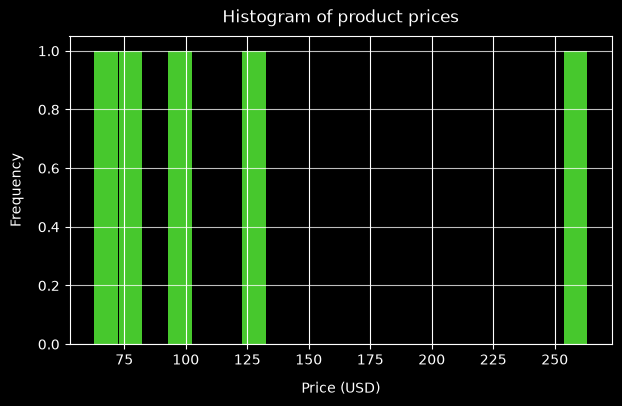

In [14]:
# Plot Histogram
fig = plt.figure( figsize=(7,4))
plt.xticks(fontsize=14, rotation=0)
plt.yticks(fontsize=14, rotation=0)
n, bins, patches = plt.hist(x=df_sub['price'], 
                            bins=20, 
                            color="#47C82D",
                            alpha=1.00, 
                            rwidth=0.95
                   )
plt.grid(True)
plt.ticklabel_format(style='plain')
plt.grid(axis='y', alpha=0.75)

# Set labels
plt.xlabel('Price (USD)', fontsize=10, labelpad=10)
plt.ylabel('Frequency', fontsize=10, labelpad=10)
plt.title('Histogram of product prices', fontsize=12, pad=10)

# Set fontsize of tick labels
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)

plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each notebook)

In [15]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1064-azure
Datetime: 2026-09-25 07:46:07
Python Version: 3.14.2
-----------------------------------
